In [5]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    average_precision_score,
    classification_report,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [6]:
PROJECT_ROOT = Path.cwd().parent
train_path = PROJECT_ROOT / "all_datasets" / "heart_failure_dataset" / "heart.csv"
df = pd.read_csv(train_path)

In [7]:
X = df.drop(columns="HeartDisease")
y = df["HeartDisease"]

num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(exclude="number").columns.tolist()
preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), cat_cols),
])

In [8]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
model = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000)),
])
model.fit(X_train, y_train)
prob = model.predict_proba(X_valid)[:, 1]
pred = (prob >= 0.50).astype(int)

print(classification_report(y_valid, pred, digits=3))
print("ROC AUC:", round(roc_auc_score(y_valid, prob), 3))
print("PR AUC:", round(average_precision_score(y_valid, prob), 3))

              precision    recall  f1-score   support

           0      0.896     0.835     0.864       103
           1      0.873     0.921     0.897       127

    accuracy                          0.883       230
   macro avg      0.884     0.878     0.880       230
weighted avg      0.883     0.883     0.882       230

ROC AUC: 0.932
PR AUC: 0.941


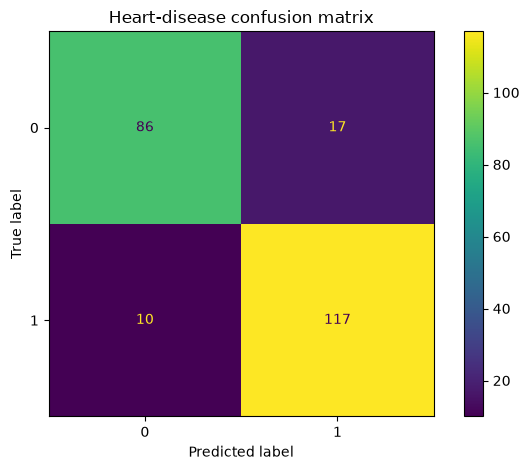

In [9]:
ConfusionMatrixDisplay.from_predictions(y_valid, pred)
plt.title("Heart-disease confusion matrix")
plt.tight_layout()
plt.show()

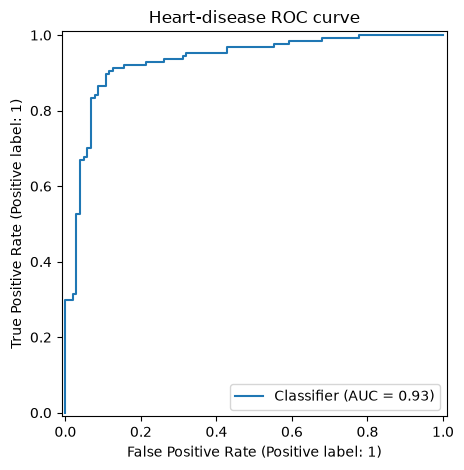

In [10]:
RocCurveDisplay.from_predictions(y_valid, prob)
plt.title("Heart-disease ROC curve")
plt.tight_layout()
plt.show()

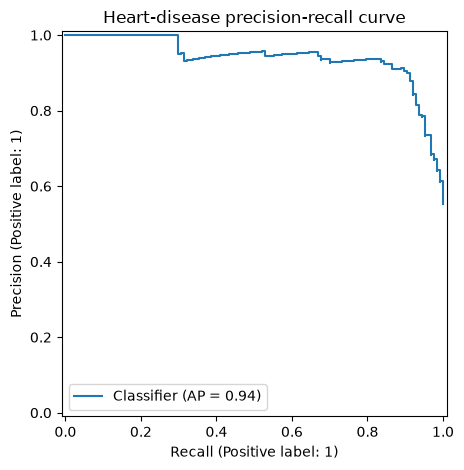

In [11]:
PrecisionRecallDisplay.from_predictions(y_valid, prob)
plt.title("Heart-disease precision-recall curve")
plt.tight_layout()
plt.show()